# Probabilistic Graphical Model Comparison

Compares four PGM structures for classifying `Problem_SKU`:

| Model | Structure |
|---|---|
| GaussianNB (sklearn) | All features independent given class — baseline |
| Naive Bayes (pgmpy) | Same, but exact discrete distribution per feature |
| TAN | Naive Bayes + one spanning tree of feature-feature edges |
| Bayesian Network (Hill Climbing) | Full structure learned from data via BDeu score |

Continuous features are quantile-binned to 3 levels (0/1/2) for the pgmpy models. Classification uses joint log-probability: `P(target | features) ∝ P(target, features)`.

In [26]:
import subprocess, sys
try:
    import pgmpy
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pgmpy', '-q'])
import pgmpy
print(f'pgmpy {pgmpy.__version__}')

pgmpy 1.1.2


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score, precision_recall_curve,
)
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import HillClimbSearch, BDeu, TreeSearch
from pgmpy.parameter_estimator import DiscreteBayesianEstimator

BDEU = DiscreteBayesianEstimator(prior_type='BDeu', equivalent_sample_size=5)

path = r"..\Data\SyntheticData\2026_05_23_15_21_27\std_synthetic_data_2026_05_23_15_21_27.csv"
df = pd.read_csv(path)
target = "Problem_SKU"

numeric_features = [
    "Global_SKU_Defect_Rate_%_std",
    "ABS_Volume_Difference_std",
    "Aisle_Hold_%_std",
    "#_Pick_Events_std",
    "#_Pick_Events_In_Clique_std",
    "#_Picks_std",
    "#_Picks_In_Clique_std",
    "Time_In_Loc_std",
    "Current_Max_Volume_std",
]

size_dummies = pd.get_dummies(df['Storage_Size'], prefix='Size', drop_first=True).astype(int)
binary_cols = list(size_dummies.columns) + ['Defect_In_Linked_Receive']
defect_linked_num = df['Defect_In_Linked_Receive'].astype(int)

X = pd.concat([df[numeric_features], size_dummies, defect_linked_num], axis=1)
y = df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

all_features = list(X.columns)
print(f"Train: {X_train.shape}  Test: {X_test.shape}")
print(f"Problem_SKU base rate: {y_test.mean():.3f}")


Train: (220000, 13)  Test: (55000, 13)
Problem_SKU base rate: 0.074


In [28]:
# ── Discretization ──────────────────────────────────────────────────────────
def discretize(X_train, X_test, numeric_cols, n_bins=3):
    """Quantile-bin continuous features on train; apply same edges to test."""
    Xtr = X_train.copy()
    Xte = X_test.copy()
    for col in numeric_cols:
        edges = X_train[col].quantile(np.linspace(0, 1, n_bins + 1)).values.copy()
        edges[0], edges[-1] = -np.inf, np.inf
        Xtr[col] = pd.cut(X_train[col], bins=edges, labels=range(n_bins),
                          include_lowest=True).astype(int)
        Xte[col] = pd.cut(X_test[col],  bins=edges, labels=range(n_bins),
                          include_lowest=True).astype(int)
    return Xtr, Xte

X_train_disc, X_test_disc = discretize(X_train, X_test, numeric_features)

# pgmpy needs a single DataFrame with the target included for fitting
train_disc = X_train_disc.copy()
train_disc[target] = y_train.values
test_disc = X_test_disc.copy()   # target excluded — added during inference

print("Discretized (sample):")
print(X_train_disc[numeric_features[:3]].head(3))


Discretized (sample):
        Global_SKU_Defect_Rate_%_std  ABS_Volume_Difference_std  \
175719                             1                          2   
209266                             0                          1   
71949                              2                          0   

        Aisle_Hold_%_std  
175719                 0  
209266                 0  
71949                  1  


In [29]:
# ── Helpers ──────────────────────────────────────────────────────────────────
def eval_model(name, y_true, y_proba):
    y_pred = (y_proba >= 0.5).astype(int)
    row = {
        "name":      name,
        "auc":       roc_auc_score(y_true, y_proba),
        "ap":        average_precision_score(y_true, y_proba),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall":    recall_score(y_true, y_pred, zero_division=0),
        "f1":        f1_score(y_true, y_pred, zero_division=0),
        "proba":     y_proba,
    }
    print(f"\n{name}")
    print(f"  AUC={row['auc']:.4f}  AP={row['ap']:.4f}  "
          f"P={row['precision']:.3f}  R={row['recall']:.3f}  F1={row['f1']:.3f}")
    return row


def bn_predict_proba(model, X_disc, target):
    """
    Vectorized P(target=1 | features) via joint log-probability.
    Works for any DAG structure when all features are observed.
    X_disc must NOT contain the target column.
    """
    cpds = {cpd.variable: cpd for cpd in model.cpds}
    target_states = list(cpds[target].state_names[target])

    # Pre-build reshaped value arrays + state-index maps for each CPD
    cpd_info = {}
    for node, cpd in cpds.items():
        parents  = cpd.variables[1:]
        smap     = {s: i for i, s in enumerate(cpd.state_names[node])}
        pmaps    = [{s: i for i, s in enumerate(cpd.state_names[p])} for p in parents]
        n_node   = len(smap)
        n_par    = [len(m) for m in pmaps]
        vals     = cpd.values.reshape([n_node] + n_par) if parents else cpd.values.flatten()
        cpd_info[node] = (parents, smap, pmaps, vals)

    X_arr = X_disc.reset_index(drop=True)
    log_joint = np.zeros((len(X_arr), len(target_states)))

    for cls_idx, cls_val in enumerate(target_states):
        obs = X_arr.copy()
        obs[target] = cls_val          # fix class value for joint computation
        lp  = np.zeros(len(obs))

        for node, (parents, smap, pmaps, vals) in cpd_info.items():
            node_idxs = np.array([smap[v] for v in obs[node].values])
            if not parents:
                lp += np.log(vals[node_idxs] + 1e-15)
            else:
                pidxs = tuple(
                    np.array([pm[v] for v in obs[p].values])
                    for p, pm in zip(parents, pmaps)
                )
                lp += np.log(vals[(node_idxs,) + pidxs] + 1e-15)

        log_joint[:, cls_idx] = lp

    log_joint -= log_joint.max(axis=1, keepdims=True)
    probs = np.exp(log_joint)
    probs /= probs.sum(axis=1, keepdims=True)
    return probs[:, target_states.index(1)]


def draw_dag(model, title, figsize=(14, 9)):
    G = nx.DiGraph(model.edges())
    G.add_nodes_from(model.nodes())
    colors = ['coral' if n == target else 'lightsteelblue' for n in G.nodes()]
    pos    = nx.spring_layout(G, seed=42, k=2.5)
    fig, ax = plt.subplots(figsize=figsize)
    nx.draw_networkx(
        G, pos, ax=ax,
        node_color=colors, node_size=2200, font_size=6,
        arrows=True, arrowsize=18, edge_color='steelblue',
        connectionstyle='arc3,rad=0.08',
    )
    ax.set_title(f"{title}\n(coral = {target})", fontsize=12)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

## Model 1 — GaussianNB (sklearn)

All features treated as independent Gaussians given the class. No graph structure — every feature is a direct child of the class node and nothing else.

In [30]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_proba_gnb = gnb.predict_proba(X_test)[:, 1]
results = [eval_model("GaussianNB (sklearn)", y_test, y_proba_gnb)]


GaussianNB (sklearn)
  AUC=0.8330  AP=0.3401  P=0.296  R=0.442  F1=0.355


## Model 2 — Naive Bayes (pgmpy, exact discrete)

Same independence structure as GaussianNB but uses the empirical discrete distribution over quantile bins rather than assuming Gaussian shape. Parameters estimated with BDeu (Bayesian Dirichlet equivalent uniform) prior to handle sparse combinations.

In [31]:
nb_edges = [(target, f) for f in all_features]
nb_model = DiscreteBayesianNetwork(nb_edges)
nb_model.fit(train_disc, estimator=BDEU)

y_proba_nb = bn_predict_proba(nb_model, test_disc, target)
results.append(eval_model("Naive Bayes (pgmpy, exact)", y_test, y_proba_nb))



Naive Bayes (pgmpy, exact)
  AUC=0.8089  AP=0.2936  P=0.570  R=0.059  F1=0.107


## Model 3 — TAN (Tree-Augmented Naive Bayes)

Extends Naive Bayes by adding a maximum-weight spanning tree of feature-feature edges, where edge weights are the conditional mutual information `I(X_i; X_j | class)`. Each feature now has at most two parents: the class node and one other feature.

Learning TAN structure...

TAN (Tree-Augmented NB)
  AUC=0.8100  AP=0.2949  P=0.582  R=0.063  F1=0.114


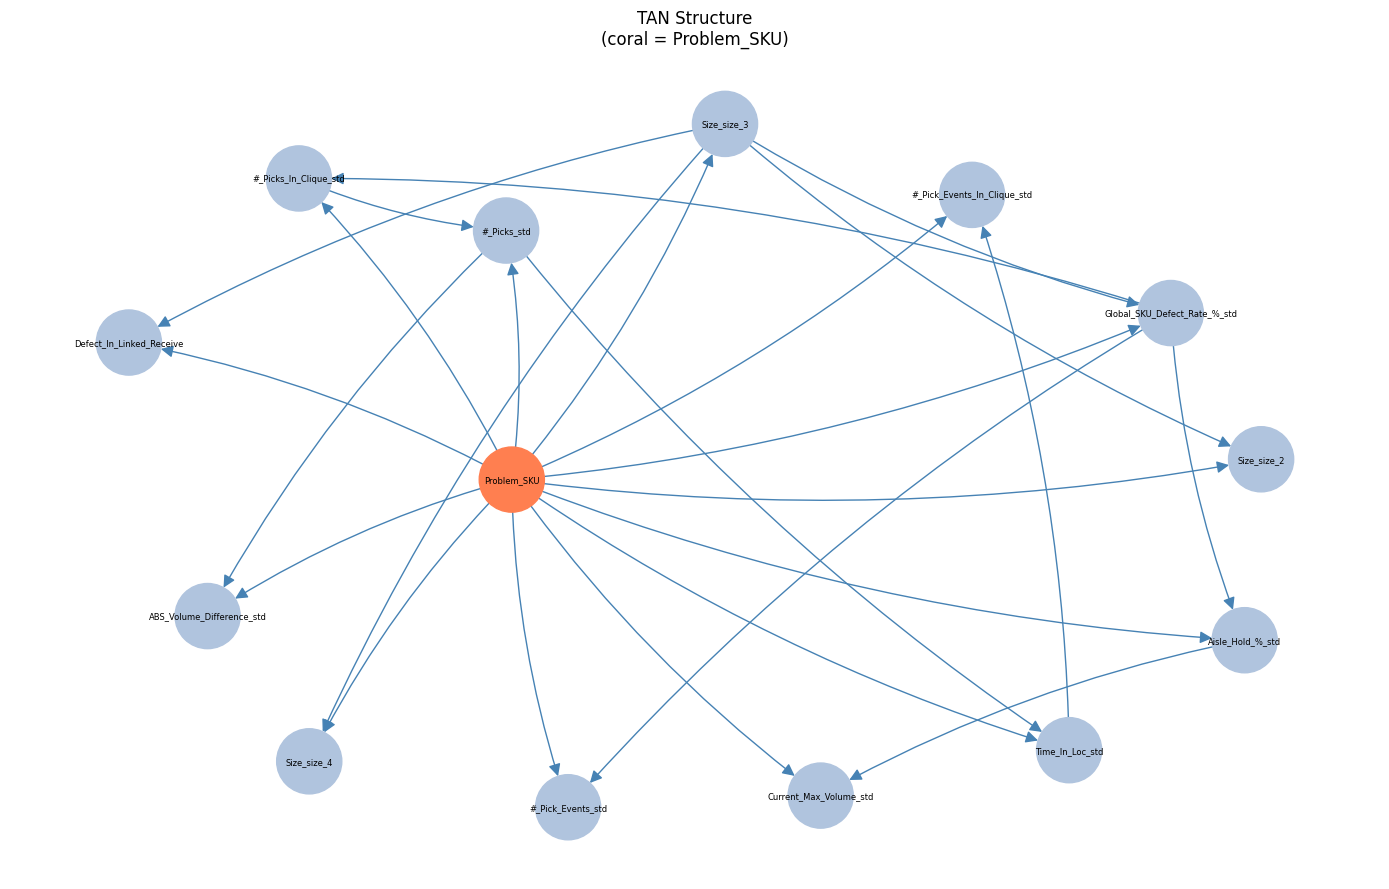

In [32]:
print("Learning TAN structure...")
tan_est = TreeSearch(train_disc)
tan_dag  = tan_est.estimate(estimator_type='tan', class_node=target,
                             show_progress=False)
tan_model = DiscreteBayesianNetwork(tan_dag.edges())
tan_model.fit(train_disc, estimator=BDEU)

y_proba_tan = bn_predict_proba(tan_model, test_disc, target)
results.append(eval_model("TAN (Tree-Augmented NB)", y_test, y_proba_tan))

draw_dag(tan_model, "TAN Structure")


## Model 4 — Bayesian Network (Hill Climbing)

Greedy search over DAG space, adding/removing/reversing edges to maximise the BIC score. Structure learned on a 50k subsample (sufficient for structure; faster than 220k). Parameters fit on the full training set.

Learning BN structure via Hill Climbing (50k subsample)...


C:\Users\myfir\AppData\Local\Temp\ipykernel_35628\746092988.py:4: FutureWarning: HillClimbSearch is deprecated and will be removed in v1.3.0. Please use
            pgmpy.causal_discovery.HillClimbSearch instead.
  hc     = HillClimbSearch(train_sample)


Edges found: 17

Bayesian Network (Hill Climbing)
  AUC=0.8107  AP=0.2959  P=0.582  R=0.066  F1=0.119


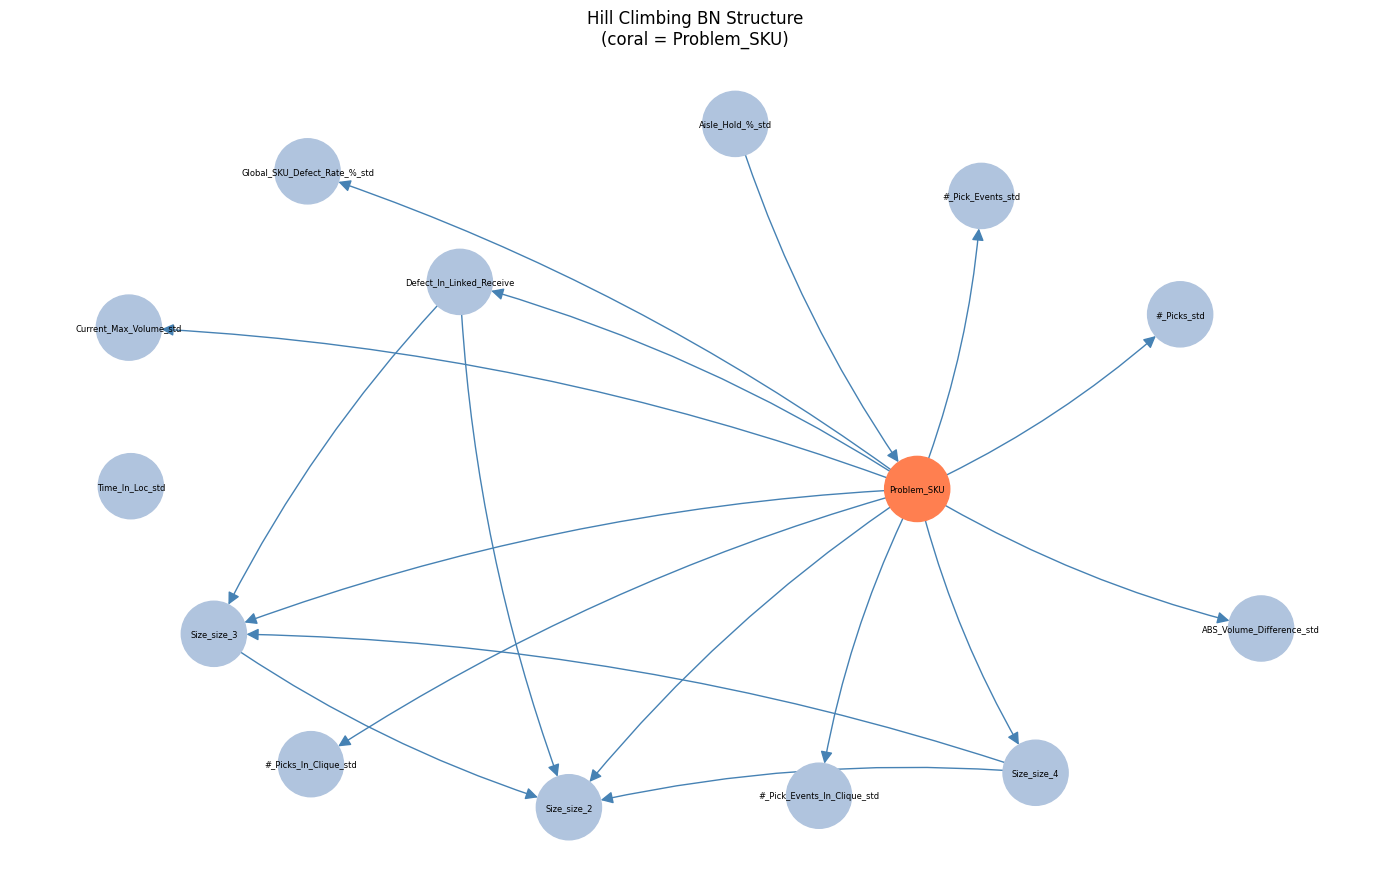

In [33]:
print("Learning BN structure via Hill Climbing (50k subsample)...")
train_sample = train_disc.sample(50_000, random_state=42)

hc     = HillClimbSearch(train_sample)
hc_dag = hc.estimate(
    scoring_method=BDeu(train_sample),
    max_iter=300,
    tabu_length=10,
    show_progress=False,
)
print(f"Edges found: {len(hc_dag.edges())}")

hc_model = DiscreteBayesianNetwork(hc_dag.edges())
for node in train_disc.columns:
    if node not in hc_model.nodes():
        hc_model.add_node(node)

hc_model.fit(train_disc, estimator=BDEU)

y_proba_hc = bn_predict_proba(hc_model, test_disc, target)
results.append(eval_model("Bayesian Network (Hill Climbing)", y_test, y_proba_hc))

draw_dag(hc_model, "Hill Climbing BN Structure")


## Comparison


Model Comparison (sorted by AUC):
                            name      auc       ap  precision   recall       f1
            GaussianNB (sklearn) 0.833000 0.340137   0.296388 0.441837 0.354784
Bayesian Network (Hill Climbing) 0.810662 0.295918   0.582251 0.066436 0.119264
         TAN (Tree-Augmented NB) 0.809966 0.294924   0.581818 0.063225 0.114057
      Naive Bayes (pgmpy, exact) 0.808880 0.293601   0.570071 0.059274 0.107383


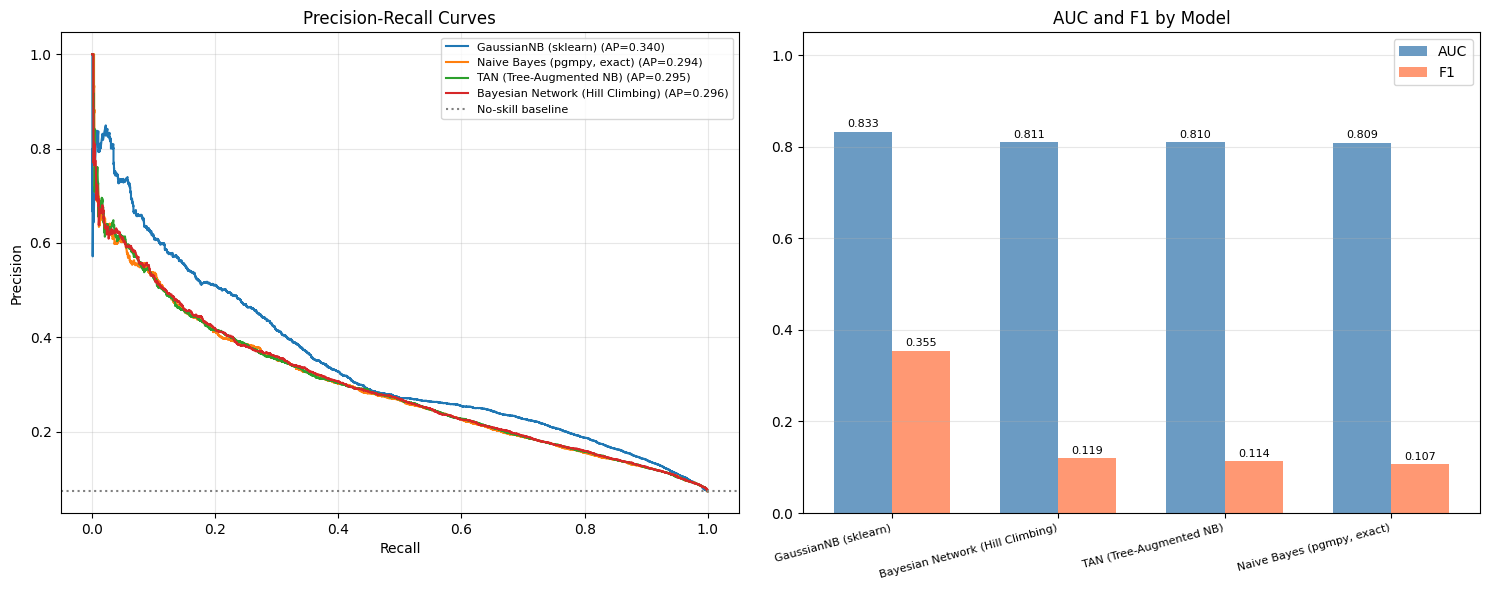

In [34]:
# ── Summary table ─────────────────────────────────────────────────────────────
comp_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'proba'} for r in results
]).sort_values('auc', ascending=False).reset_index(drop=True)

print("\nModel Comparison (sorted by AUC):")
print(comp_df.to_string(index=False))

# ── Precision-Recall curves ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
for r in results:
    p, rec, _ = precision_recall_curve(y_test, r['proba'])
    ax.plot(rec, p, label=f"{r['name']} (AP={r['ap']:.3f})")
ax.axhline(y_test.mean(), color='gray', linestyle=':', label='No-skill baseline')
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ── Bar chart: AUC and F1 ─────────────────────────────────────────────────────
ax2 = axes[1]
x  = np.arange(len(comp_df))
w  = 0.35
ax2.bar(x - w/2, comp_df['auc'], width=w, label='AUC',  color='steelblue', alpha=0.8)
ax2.bar(x + w/2, comp_df['f1'],  width=w, label='F1',   color='coral',     alpha=0.8)
for i, (auc, f1) in enumerate(zip(comp_df['auc'], comp_df['f1'])):
    ax2.text(i - w/2, auc + 0.005, f"{auc:.3f}", ha='center', va='bottom', fontsize=8)
    ax2.text(i + w/2, f1  + 0.005, f"{f1:.3f}",  ha='center', va='bottom', fontsize=8)
ax2.set_xticks(x)
ax2.set_xticklabels(comp_df['name'], rotation=15, ha='right', fontsize=8)
ax2.set_ylim(0, 1.05)
ax2.set_title("AUC and F1 by Model")
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()